# Exploratory Data Analysis — VTUAV-det

Notebook thực hiện EDA cho bộ dữ liệu **VTUAV-det** theo đúng thứ tự:

1. Dataset overview
2. Data quality check
3. Image Resolution Analysis
4. Class distribution
5. Bounding-box analysis
6. Spatial distribution
7. Pixel / intensity analysis

Mỗi phần đều có **Insight & đánh giá** được sinh trực tiếp từ kết quả tính toán. Notebook cũng tự xuất báo cáo `VTUAV-det_EDA.md` cùng tên khi chạy đến cell cuối.

## Thiết lập và quy ước

- `train_ir.json` và `val_ir.json` là annotation **COCO** chuẩn dùng trong phân tích; bbox có dạng `[x, y, width, height]`.
- Split `val` trong JSON ánh xạ tới thư mục vật lý `test/`. Thư mục này có ảnh và nhãn, nên được xem là validation của bản phát hành hiện tại.
- Mỗi sample là một cặp ảnh đã căn chỉnh `rgb`–`ir` dùng chung annotation.
- Pascal VOC XML trong `<split>/anno/` được audit như nguồn nhãn phụ.
- Kiểm tra file, corrupt và kích thước chạy trên toàn bộ ảnh. Phân tích pixel dùng mẫu ngẫu nhiên cố định để giảm thời gian và RAM.
- Nhóm bbox small/medium/large dùng ngưỡng COCO theo diện tích pixel: `<32²`, `32²–96²`, `≥96²`.

In [1]:
from pathlib import Path
import json
import warnings
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
ImageFile.LOAD_TRUNCATED_IMAGES = False
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_ROOT = Path("VTUAV-det")
if not DATA_ROOT.exists() and Path.cwd().name == "VTUAV-det":
    DATA_ROOT = Path.cwd()
DATA_ROOT = DATA_ROOT.resolve()
assert DATA_ROOT.exists(), f"Không tìm thấy dataset: {DATA_ROOT}"

SPLITS = {
    "train": {"json": "train_ir.json", "folder": "train"},
    "val": {"json": "val_ir.json", "folder": "test"},
}
MODALITIES = ("rgb", "ir")
SEED = 42
PIXEL_SAMPLE_PER_GROUP = 200
PIXEL_RESIZE = (128, 128)

print("DATA_ROOT:", DATA_ROOT)
print("Pixel sample:", PIXEL_SAMPLE_PER_GROUP, "ảnh / split / modality; resize", PIXEL_RESIZE)

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\GIANG\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


DATA_ROOT: G:\Capstone\code\Data\VTUAV-det
Pixel sample: 200 ảnh / split / modality; resize (128, 128)


## 1. Dataset overview (số lượng mẫu train/val, số class, format)

In [2]:
coco = {}
image_rows, ann_rows = [], []

for split, cfg in SPLITS.items():
    with open(DATA_ROOT / cfg["json"], "r", encoding="utf-8") as f:
        data = json.load(f)
    coco[split] = data
    for im in data.get("images", []):
        image_rows.append({"split": split, **im})
    for ann in data.get("annotations", []):
        x, y, w, h = ann.get("bbox", [np.nan] * 4)
        ann_rows.append({
            "split": split,
            "ann_id": ann.get("id"),
            "image_id": ann.get("image_id"),
            "category_id": ann.get("category_id"),
            "x": x, "y": y, "bbox_w": w, "bbox_h": h,
            "declared_area": ann.get("area", np.nan),
            "iscrowd": ann.get("iscrowd", 0),
            "ignore": ann.get("ignore", 0),
        })

images_df = pd.DataFrame(image_rows)
anns_df = pd.DataFrame(ann_rows)
categories = pd.DataFrame(coco["train"]["categories"])[["id", "name", "supercategory"]]
CAT_MAP = dict(zip(categories["id"], categories["name"]))
anns_df["class_name"] = anns_df["category_id"].map(CAT_MAP)

overview_rows = []
for split, cfg in SPLITS.items():
    split_images = images_df[images_df["split"].eq(split)]
    overview_rows.append({
        "split": split,
        "physical_folder": cfg["folder"],
        "paired_samples_COCO": len(split_images),
        "rgb_files": len(list((DATA_ROOT / cfg["folder"] / "rgb").glob("*"))),
        "ir_files": len(list((DATA_ROOT / cfg["folder"] / "ir").glob("*"))),
        "xml_files": len(list((DATA_ROOT / cfg["folder"] / "anno").glob("*.xml"))),
        "objects_COCO": int((anns_df["split"] == split).sum()),
    })
overview_df = pd.DataFrame(overview_rows).set_index("split")

display(overview_df)
display(categories)
print(f"Tổng sample ghép cặp: {len(images_df):,}")
print(f"Tổng ảnh vật lý kỳ vọng (2 modality): {2 * len(images_df):,}")
print(f"Tổng object: {len(anns_df):,}")
print("Định dạng: JPEG RGB/IR; COCO JSON chính; Pascal VOC XML phụ")

,physical_folder,paired_samples_COCO,rgb_files,ir_files,xml_files,objects_COCO
split,,,,,,
train,train,11392,11392,11392,11392,76314
val,test,5378,5378,5378,5345,48555


,id,name,supercategory
0,0,person,none
1,1,rider,none
2,2,crowd,none
3,3,uncertain,none


Tổng sample ghép cặp: 16,770
Tổng ảnh vật lý kỳ vọng (2 modality): 33,540
Tổng object: 124,869
Định dạng: JPEG RGB/IR; COCO JSON chính; Pascal VOC XML phụ


In [3]:
train_share = (images_df["split"] == "train").mean()
same_categories = coco["train"]["categories"] == coco["val"]["categories"]
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- Có **{len(images_df):,} sample ghép cặp RGB–IR**, gồm "
    f"**{overview_df.loc['train', 'paired_samples_COCO']:,} train** và "
    f"**{overview_df.loc['val', 'paired_samples_COCO']:,} val** "
    f"({train_share:.1%}/{1-train_share:.1%}).\n"
    f"- Dataset có **{len(CAT_MAP)} class**: " + ", ".join(f"`{v}`" for v in CAT_MAP.values()) + ".\n"
    f"- Hai split {'dùng cùng category mapping' if same_categories else 'KHÔNG dùng cùng category mapping'}. "
    "COCO JSON nên là nguồn nhãn chính vì bao phủ trực tiếp danh sách ảnh; XML được dùng để đối chiếu chất lượng.\n"
    "- Tên `val_ir.json` nhưng dữ liệu nằm trong `test/`; pipeline cần ánh xạ rõ như notebook này để tránh đọc sai split."
))

**Insight & đánh giá**

- Có **16,770 sample ghép cặp RGB–IR**, gồm **11,392 train** và **5,378 val** (67.9%/32.1%).
- Dataset có **4 class**: `person`, `rider`, `crowd`, `uncertain`.
- Hai split dùng cùng category mapping. COCO JSON nên là nguồn nhãn chính vì bao phủ trực tiếp danh sách ảnh; XML được dùng để đối chiếu chất lượng.
- Tên `val_ir.json` nhưng dữ liệu nằm trong `test/`; pipeline cần ánh xạ rõ như notebook này để tránh đọc sai split.

## 2. Data quality check (corrupt, size, missing label, wrong bbox)

Các kiểm tra gồm: thiếu ảnh theo COCO, ảnh không đọc được/corrupt, kích thước thực khác metadata, RGB–IR lệch kích thước, thiếu XML, ảnh không có object, ID trùng/tham chiếu sai, category lạ, bbox không hữu hạn/không dương/vượt biên và `area` khai báo không khớp `w×h`.

In [4]:
def inspect_image(path):
    try:
        with Image.open(path) as im:
            width, height = im.size
            mode, fmt = im.mode, im.format
            im.verify()
        return True, width, height, mode, fmt, None
    except Exception as exc:
        return False, np.nan, np.nan, None, None, f"{type(exc).__name__}: {exc}"

quality_rows = []
for row in images_df.itertuples(index=False):
    folder = SPLITS[row.split]["folder"]
    for modality in MODALITIES:
        path = DATA_ROOT / folder / modality / row.file_name
        exists = path.is_file()
        result = inspect_image(path) if exists else (False, np.nan, np.nan, None, None, "missing")
        readable, aw, ah, mode, fmt, error = result
        quality_rows.append({
            "split": row.split, "image_id": row.id, "file_name": row.file_name,
            "modality": modality, "path": str(path), "exists": exists,
            "readable": readable, "actual_width": aw, "actual_height": ah,
            "mode": mode, "format": fmt, "error": error,
            "metadata_width": row.width, "metadata_height": row.height,
            "size_mismatch_metadata": bool(readable and (aw != row.width or ah != row.height)),
        })
quality_df = pd.DataFrame(quality_rows)

# Audit file name sets.
audit_rows = []
missing_xml_details = {}
unexpected_sidecars = []
for split, cfg in SPLITS.items():
    expected = set(images_df.loc[images_df["split"].eq(split), "file_name"])
    expected_stems = {Path(x).stem for x in expected}
    for modality in MODALITIES:
        actual = {p.name for p in (DATA_ROOT / cfg["folder"] / modality).glob("*") if p.is_file()}
        audit_rows.append({"split": split, "component": modality, "expected": len(expected),
                           "found": len(actual), "missing": len(expected-actual), "extra": len(actual-expected)})
    anno_dir = DATA_ROOT / cfg["folder"] / "anno"
    xml_stems = {p.stem for p in anno_dir.glob("*.xml")}
    missing_xml_details[split] = sorted(expected_stems - xml_stems)
    extra_xml = xml_stems - expected_stems
    audit_rows.append({"split": split, "component": "XML label", "expected": len(expected_stems),
                       "found": len(xml_stems), "missing": len(expected_stems-xml_stems), "extra": len(extra_xml)})
    unexpected_sidecars.extend({"split": split, "file": p.name, "suffix": p.suffix}
                               for p in anno_dir.glob("*") if p.is_file() and p.suffix.lower() != ".xml")

file_audit_df = pd.DataFrame(audit_rows)

# Pair-size check.
pair_dims = quality_df.pivot(index=["split", "image_id", "file_name"], columns="modality",
                             values=["actual_width", "actual_height"])
pair_dims["pair_size_mismatch"] = (
    pair_dims[("actual_width", "rgb")] != pair_dims[("actual_width", "ir")]
) | (
    pair_dims[("actual_height", "rgb")] != pair_dims[("actual_height", "ir")]
)

display(file_audit_df)
print("Corrupt/unreadable:", int((quality_df["exists"] & ~quality_df["readable"]).sum()))
print("Thiếu ảnh theo COCO:", int((~quality_df["exists"]).sum()))
print("Ảnh lệch metadata:", int(quality_df["size_mismatch_metadata"].sum()))
print("Cặp RGB–IR lệch kích thước:", int(pair_dims["pair_size_mismatch"].sum()))
print("Sidecar không phải XML:", unexpected_sidecars)
print("Ví dụ XML thiếu:", {k: v[:15] for k, v in missing_xml_details.items()})

,split,component,expected,found,missing,extra
0,train,rgb,11392,11392,0,0
1,train,ir,11392,11392,0,0
2,train,XML label,11392,11392,0,0
3,val,rgb,5378,5378,0,0
4,val,ir,5378,5378,0,0
5,val,XML label,5378,5345,33,0


Corrupt/unreadable: 0
Thiếu ảnh theo COCO: 0
Ảnh lệch metadata: 0
Cặp RGB–IR lệch kích thước: 0
Sidecar không phải XML: [{'split': 'train', 'file': '03726.txt', 'suffix': '.txt'}, {'split': 'train', 'file': '05850.json', 'suffix': '.json'}, {'split': 'train', 'file': 'classes.txt', 'suffix': '.txt'}]
Ví dụ XML thiếu: {'train': [], 'val': ['00273', '00472', '00473', '00474', '02125', '02126', '02127', '02128', '02129', '02130', '02131', '02242', '02243', '02244', '02598']}


In [5]:
# Kiểm tra annotation COCO.
img_dims = images_df[["split", "id", "width", "height"]].rename(
    columns={"id": "image_id", "width": "image_width", "height": "image_height"}
)
bbox_df = anns_df.merge(img_dims, on=["split", "image_id"], how="left", validate="many_to_one")
numeric_cols = ["x", "y", "bbox_w", "bbox_h"]
finite = np.isfinite(bbox_df[numeric_cols].astype(float)).all(axis=1)
bbox_df["missing_image_ref"] = bbox_df["image_width"].isna()
bbox_df["unknown_category"] = bbox_df["class_name"].isna()
bbox_df["non_finite_bbox"] = ~finite
bbox_df["non_positive_bbox"] = (bbox_df["bbox_w"] <= 0) | (bbox_df["bbox_h"] <= 0)
bbox_df["outside_bbox"] = (
    (bbox_df["x"] < 0) | (bbox_df["y"] < 0) |
    (bbox_df["x"] + bbox_df["bbox_w"] > bbox_df["image_width"]) |
    (bbox_df["y"] + bbox_df["bbox_h"] > bbox_df["image_height"])
)
bbox_df["area_mismatch"] = ~np.isclose(
    bbox_df["declared_area"].astype(float),
    bbox_df["bbox_w"].astype(float) * bbox_df["bbox_h"].astype(float),
    rtol=0, atol=1e-6, equal_nan=False
)
bbox_df["wrong_bbox"] = bbox_df[["non_finite_bbox", "non_positive_bbox", "outside_bbox"]].any(axis=1)

objects_per_image_base = anns_df.groupby(["split", "image_id"]).size()
empty_images = images_df.set_index(["split", "id"]).index.difference(objects_per_image_base.index)
empty_image_rows = images_df.set_index(["split", "id"]).loc[empty_images].reset_index()
empty_stems_by_split = {
    split: {Path(x).stem for x in empty_image_rows.loc[empty_image_rows["split"].eq(split), "file_name"]}
    for split in SPLITS
}

annotation_audit = pd.Series({
    "duplicate_image_id_within_split": int(images_df.duplicated(["split", "id"]).sum()),
    "duplicate_annotation_id_within_split": int(anns_df.duplicated(["split", "ann_id"]).sum()),
    "missing_image_reference": int(bbox_df["missing_image_ref"].sum()),
    "unknown_category": int(bbox_df["unknown_category"].sum()),
    "non_finite_bbox": int(bbox_df["non_finite_bbox"].sum()),
    "non_positive_bbox": int(bbox_df["non_positive_bbox"].sum()),
    "bbox_outside_image": int(bbox_df["outside_bbox"].sum()),
    "wrong_bbox_total": int(bbox_df["wrong_bbox"].sum()),
    "declared_area_mismatch": int(bbox_df["area_mismatch"].sum()),
    "images_without_objects": len(empty_images),
}, name="count").to_frame()
display(annotation_audit)

if bbox_df["wrong_bbox"].any():
    display(bbox_df.loc[bbox_df["wrong_bbox"],
                        ["split", "ann_id", "image_id", "class_name", "x", "y", "bbox_w", "bbox_h",
                         "image_width", "image_height", "non_positive_bbox", "outside_bbox"]].head(30))
if len(empty_images):
    print("Ví dụ ảnh không có object:", list(empty_images[:20]))

,count
duplicate_image_id_within_split,0
duplicate_annotation_id_within_split,0
missing_image_reference,0
unknown_category,0
non_finite_bbox,0
non_positive_bbox,20
bbox_outside_image,0
wrong_bbox_total,20
declared_area_mismatch,0
images_without_objects,40


,split,ann_id,image_id,class_name,x,y,bbox_w,bbox_h,image_width,image_height,non_positive_bbox,outside_bbox
19770,train,19770,3256,person,1162,130,0,30,1920,1080,True,False
51059,train,51059,6858,person,109,0,67,0,1920,1080,True,False
92999,val,16685,1530,person,1117,272,0,4,1920,1080,True,False
117245,val,40931,4391,person,1031,408,0,10,1920,1080,True,False
117424,val,41110,4401,person,1244,147,0,2,1920,1080,True,False
117467,val,41153,4403,person,1565,436,0,2,1920,1080,True,False
117676,val,41362,4413,person,733,850,0,2,1920,1080,True,False
119174,val,42860,4514,person,1366,992,0,1,1920,1080,True,False
119840,val,43526,4575,person,753,141,0,2,1920,1080,True,False
119965,val,43651,4595,person,1266,884,0,1,1920,1080,True,False


Ví dụ ảnh không có object: [('train', 4287), ('train', 4288), ('train', 4290), ('train', 4291), ('train', 4292), ('train', 5825), ('train', 6969), ('val', 140), ('val', 272), ('val', 471), ('val', 472), ('val', 473), ('val', 2124), ('val', 2125), ('val', 2126), ('val', 2127), ('val', 2128), ('val', 2129), ('val', 2130), ('val', 2241)]


In [6]:
n_corrupt = int((quality_df["exists"] & ~quality_df["readable"]).sum())
n_missing_img = int((~quality_df["exists"]).sum())
n_size_mismatch = int(quality_df["size_mismatch_metadata"].sum())
n_pair_mismatch = int(pair_dims["pair_size_mismatch"].sum())
n_missing_xml = int(file_audit_df.loc[file_audit_df["component"].eq("XML label"), "missing"].sum())
n_missing_xml_empty = sum(
    len(set(missing_xml_details[split]) & empty_stems_by_split[split]) for split in SPLITS
)
n_missing_xml_with_objects = n_missing_xml - n_missing_xml_empty
n_wrong_bbox = int(bbox_df["wrong_bbox"].sum())
n_empty = len(empty_images)

display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- Trên **{len(quality_df):,} file ảnh kỳ vọng**, phát hiện **{n_missing_img} ảnh thiếu**, "
    f"**{n_corrupt} ảnh corrupt/unreadable**, **{n_size_mismatch} ảnh lệch kích thước metadata** và "
    f"**{n_pair_mismatch} cặp RGB–IR lệch kích thước**.\n"
    f"- Annotation COCO có **{n_wrong_bbox} bbox sai hình học** và **{n_empty} ảnh không có object**. "
    "Ảnh không có object có thể là negative sample hợp lệ, không nên tự động xóa.\n"
    f"- Nguồn XML phụ thiếu **{n_missing_xml} file** so với danh sách COCO; "
    f"**{n_missing_xml_empty}** trong số đó là ảnh COCO không có object và "
    f"**{n_missing_xml_with_objects}** ảnh có object. "
    "Pipeline XML phải diễn giải file vắng mặt là negative sample khi phù hợp, thay vì mặc định sample bị hỏng.\n"
    f"- Có **{len(unexpected_sidecars)} file sidecar không phải XML** trong thư mục annotation; "
    "nên lọc theo đuôi `.xml` thay vì đọc mọi file trong thư mục."
))

**Insight & đánh giá**

- Trên **33,540 file ảnh kỳ vọng**, phát hiện **0 ảnh thiếu**, **0 ảnh corrupt/unreadable**, **0 ảnh lệch kích thước metadata** và **0 cặp RGB–IR lệch kích thước**.
- Annotation COCO có **20 bbox sai hình học** và **40 ảnh không có object**. Ảnh không có object có thể là negative sample hợp lệ, không nên tự động xóa.
- Nguồn XML phụ thiếu **33 file** so với danh sách COCO; **31** trong số đó là ảnh COCO không có object và **2** ảnh có object. Pipeline XML phải diễn giải file vắng mặt là negative sample khi phù hợp, thay vì mặc định sample bị hỏng.
- Có **3 file sidecar không phải XML** trong thư mục annotation; nên lọc theo đuôi `.xml` thay vì đọc mọi file trong thư mục.

## 3. Image Resolution Analysis (histogram width/height, aspect ratio)

,modality,resolution,count,percent_within_modality
0,ir,1920×1080,16770,100.0
1,rgb,1920×1080,16770,100.0


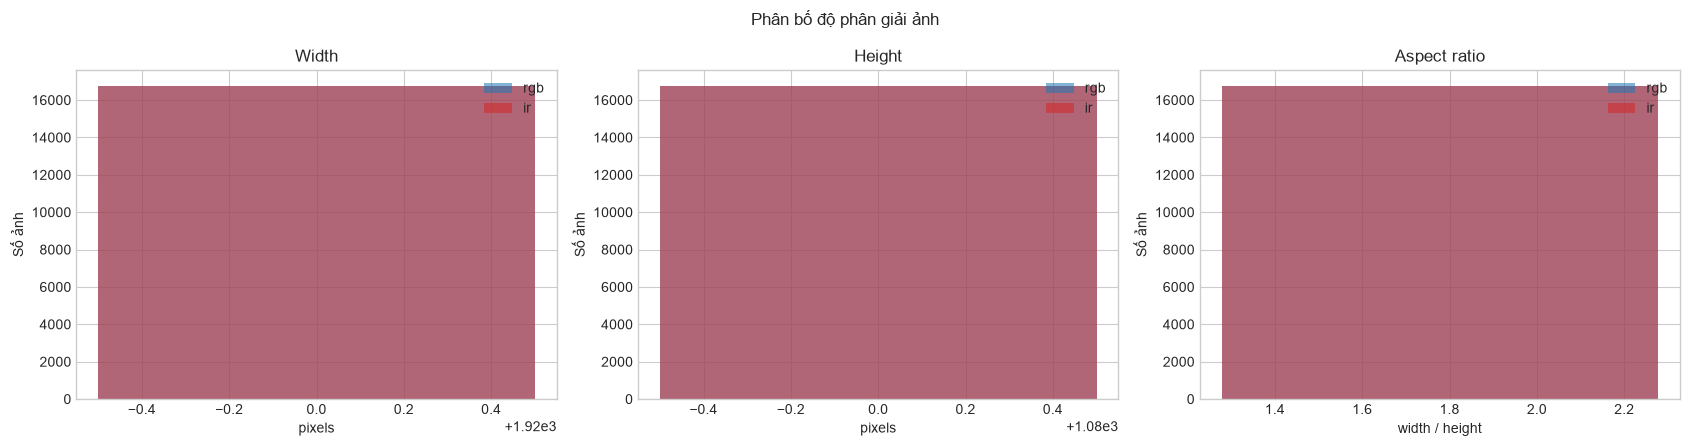

In [7]:
valid_quality = quality_df[quality_df["readable"]].copy()
valid_quality["aspect_ratio"] = valid_quality["actual_width"] / valid_quality["actual_height"]
valid_quality["resolution"] = (
    valid_quality["actual_width"].astype(int).astype(str) + "×" +
    valid_quality["actual_height"].astype(int).astype(str)
)

resolution_table = (valid_quality.groupby(["modality", "resolution"]).size()
                    .rename("count").reset_index())
resolution_table["percent_within_modality"] = (
    resolution_table["count"] / resolution_table.groupby("modality")["count"].transform("sum") * 100
)
display(resolution_table.sort_values(["modality", "count"], ascending=[True, False]).head(20))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for modality, color in [("rgb", "tab:blue"), ("ir", "tab:red")]:
    q = valid_quality[valid_quality["modality"].eq(modality)]
    axes[0].hist(q["actual_width"], bins=min(30, max(1, q["actual_width"].nunique())), alpha=.55, label=modality, color=color)
    axes[1].hist(q["actual_height"], bins=min(30, max(1, q["actual_height"].nunique())), alpha=.55, label=modality, color=color)
    axes[2].hist(q["aspect_ratio"], bins=min(30, max(1, q["aspect_ratio"].nunique())), alpha=.55, label=modality, color=color)
for ax, title, xlabel in zip(axes, ["Width", "Height", "Aspect ratio"], ["pixels", "pixels", "width / height"]):
    ax.set(title=title, xlabel=xlabel, ylabel="Số ảnh")
    ax.legend()
plt.suptitle("Phân bố độ phân giải ảnh")
plt.tight_layout()
plt.show()

In [8]:
res_counts = valid_quality["resolution"].value_counts()
top_res = res_counts.index[0]
top_res_share = res_counts.iloc[0] / len(valid_quality)
ar_min, ar_max = valid_quality["aspect_ratio"].min(), valid_quality["aspect_ratio"].max()
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- Độ phân giải phổ biến nhất là **{top_res}**, chiếm **{top_res_share:.1%}** số ảnh đọc được; "
    f"toàn bộ aspect ratio nằm trong khoảng **{ar_min:.3f}–{ar_max:.3f}**.\n"
    f"- Có **{valid_quality['resolution'].nunique()} cấu hình độ phân giải** trên cả hai modality. "
    "Nếu huấn luyện theo batch, vẫn nên resize/letterbox và biến đổi hình học đồng bộ cho RGB, IR và bbox.\n"
    f"- Số cặp lệch kích thước giữa hai modality là **{n_pair_mismatch}**; "
    "điều này quyết định có thể áp dụng cùng ma trận biến đổi hình học cho từng cặp hay không."
))

**Insight & đánh giá**

- Độ phân giải phổ biến nhất là **1920×1080**, chiếm **100.0%** số ảnh đọc được; toàn bộ aspect ratio nằm trong khoảng **1.778–1.778**.
- Có **1 cấu hình độ phân giải** trên cả hai modality. Nếu huấn luyện theo batch, vẫn nên resize/letterbox và biến đổi hình học đồng bộ cho RGB, IR và bbox.
- Số cặp lệch kích thước giữa hai modality là **0**; điều này quyết định có thể áp dụng cùng ma trận biến đổi hình học cho từng cặp hay không.

## 4. Class distribution (số lượng object mỗi class)

split,train,val,total,percent
class_name,,,,
person,74010,47114,121124,97.000857
rider,1316,898,2214,1.773058
crowd,426,429,855,0.684718
uncertain,562,114,676,0.541367


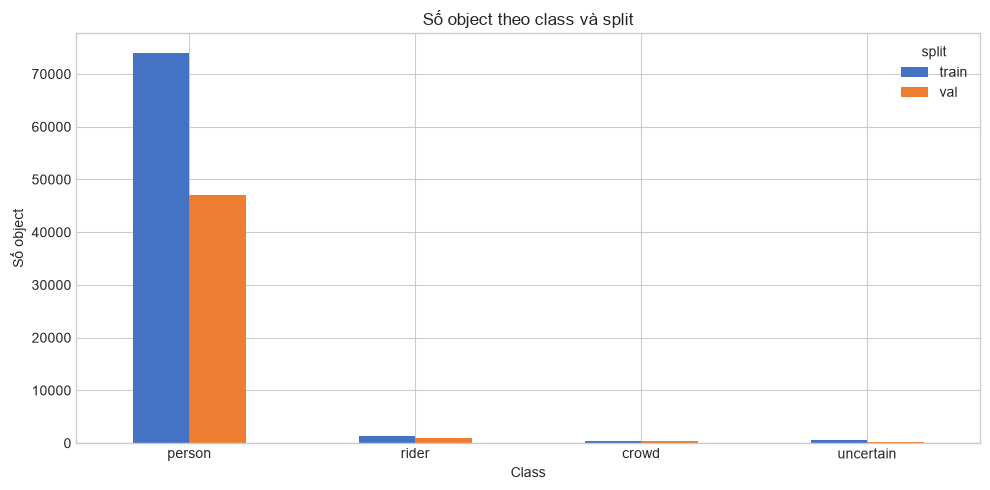

In [9]:
class_dist = (bbox_df.groupby(["class_name", "split"]).size()
              .unstack(fill_value=0).reindex(list(CAT_MAP.values()), fill_value=0))
class_dist["total"] = class_dist.sum(axis=1)
class_dist["percent"] = class_dist["total"] / class_dist["total"].sum() * 100
display(class_dist.sort_values("total", ascending=False))

ax = class_dist[[c for c in ["train", "val"] if c in class_dist]].plot(
    kind="bar", figsize=(10, 5), color=["#4472C4", "#ED7D31"]
)
ax.set(title="Số object theo class và split", xlabel="Class", ylabel="Số object")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

In [10]:
majority_class = class_dist["total"].idxmax()
minority_class = class_dist["total"].idxmin()
imbalance_ratio = class_dist.loc[majority_class, "total"] / max(class_dist.loc[minority_class, "total"], 1)
split_class_pct = class_dist[["train", "val"]].div(class_dist[["train", "val"]].sum(axis=0), axis=1) * 100
max_shift_class = (split_class_pct["train"] - split_class_pct["val"]).abs().idxmax()
max_shift = abs(split_class_pct.loc[max_shift_class, "train"] - split_class_pct.loc[max_shift_class, "val"])
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- Class lớn nhất là **`{majority_class}`** ({class_dist.loc[majority_class, 'percent']:.1f}%), "
    f"nhỏ nhất là **`{minority_class}`** ({class_dist.loc[minority_class, 'percent']:.1f}%); "
    f"tỷ lệ mất cân bằng lớn nhất/nhỏ nhất là **{imbalance_ratio:.1f}:1**.\n"
    f"- Chênh lệch tỷ trọng class lớn nhất giữa train và val thuộc `{max_shift_class}`: **{max_shift:.2f} điểm %**.\n"
    "- Nên báo cáo AP theo từng class và cân nhắc class weights, sampler hoặc augmentation; không nên chỉ nhìn mAP tổng nếu class hiếm có ý nghĩa nghiệp vụ."
))

**Insight & đánh giá**

- Class lớn nhất là **`person`** (97.0%), nhỏ nhất là **`uncertain`** (0.5%); tỷ lệ mất cân bằng lớn nhất/nhỏ nhất là **179.2:1**.
- Chênh lệch tỷ trọng class lớn nhất giữa train và val thuộc `uncertain`: **0.50 điểm %**.
- Nên báo cáo AP theo từng class và cân nhắc class weights, sampler hoặc augmentation; không nên chỉ nhìn mAP tổng nếu class hiếm có ý nghĩa nghiệp vụ.

## 5. Bounding box (small/medium/large, aspect ratio bbox, số object mỗi ảnh)

Quy ước COCO theo diện tích pixel tuyệt đối:

- **small:** area `< 32²`
- **medium:** `32² ≤ area < 96²`
- **large:** area `≥ 96²`

Do độ phân giải ảnh có thể khác nhau, notebook cũng tính `area_ratio = bbox_area / image_area`. Các phân bố hình học và spatial bên dưới loại bbox đã bị quality check đánh dấu sai; tổng object theo class vẫn phản ánh annotation gốc.

split,train,val,total,percent
size_group,,,,
small,7650,9862,17512,14.026544
medium,50795,32733,83528,66.903219
large,17867,5942,23809,19.070237


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
split,,,,,,,,,,,
train,11392.0,6.698912,12.399671,0.0,1.0,3.0,7.0,15.0,24.0,81.0,103.0
val,5378.0,9.028449,10.830019,0.0,2.0,4.0,14.0,23.0,30.0,52.0,74.0


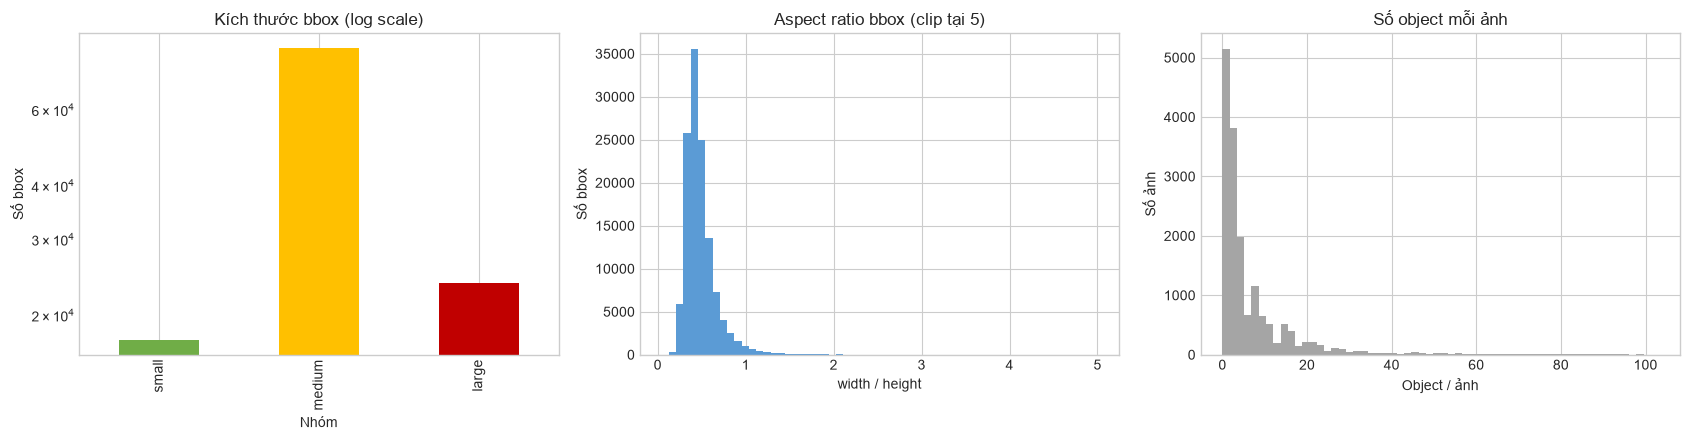

In [11]:
# Các thống kê hình học chỉ dùng bbox hợp lệ; bbox lỗi vẫn được giữ trong quality audit và class count.
analysis_bbox_df = bbox_df.loc[~bbox_df["wrong_bbox"]].copy()
analysis_bbox_df["bbox_area"] = analysis_bbox_df["bbox_w"] * analysis_bbox_df["bbox_h"]
analysis_bbox_df["area_ratio"] = analysis_bbox_df["bbox_area"] / (analysis_bbox_df["image_width"] * analysis_bbox_df["image_height"])
analysis_bbox_df["bbox_aspect_ratio"] = analysis_bbox_df["bbox_w"] / analysis_bbox_df["bbox_h"]
analysis_bbox_df["size_group"] = pd.cut(
    analysis_bbox_df["bbox_area"], bins=[-np.inf, 32**2, 96**2, np.inf],
    labels=["small", "medium", "large"], right=False
)

size_dist = (analysis_bbox_df.groupby(["size_group", "split"], observed=False).size()
             .unstack(fill_value=0).reindex(["small", "medium", "large"]))
size_dist["total"] = size_dist.sum(axis=1)
size_dist["percent"] = size_dist["total"] / size_dist["total"].sum() * 100
display(size_dist)

objects_per_image = (images_df[["split", "id"]].rename(columns={"id": "image_id"})
                     .merge(anns_df.groupby(["split", "image_id"]).size().rename("objects"),
                            on=["split", "image_id"], how="left"))
objects_per_image["objects"] = objects_per_image["objects"].fillna(0).astype(int)
display(objects_per_image.groupby("split")["objects"].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
size_dist["total"].plot(kind="bar", ax=axes[0], color=["#70AD47", "#FFC000", "#C00000"], logy=True)
axes[0].set(title="Kích thước bbox (log scale)", xlabel="Nhóm", ylabel="Số bbox")
axes[1].hist(np.clip(analysis_bbox_df["bbox_aspect_ratio"].replace([np.inf, -np.inf], np.nan).dropna(), 0, 5), bins=60, color="#5B9BD5")
axes[1].set(title="Aspect ratio bbox (clip tại 5)", xlabel="width / height", ylabel="Số bbox")
axes[2].hist(objects_per_image["objects"], bins=min(60, max(10, objects_per_image["objects"].nunique())), color="#A5A5A5")
axes[2].set(title="Số object mỗi ảnh", xlabel="Object / ảnh", ylabel="Số ảnh")
plt.tight_layout(); plt.show()

In [12]:
small_share = analysis_bbox_df["size_group"].eq("small").mean()
median_area_ratio = analysis_bbox_df["area_ratio"].median()
median_obj = objects_per_image["objects"].median()
p95_obj = objects_per_image["objects"].quantile(.95)
median_ar = analysis_bbox_df["bbox_aspect_ratio"].replace([np.inf, -np.inf], np.nan).median()
extreme_ar_share = ((analysis_bbox_df["bbox_aspect_ratio"] < .25) | (analysis_bbox_df["bbox_aspect_ratio"] > 4)).mean()
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- Sau khi loại **{n_wrong_bbox} bbox sai hình học**, **{small_share:.1%}** bbox hợp lệ là small theo chuẩn COCO; "
    f"median bbox chỉ chiếm **{median_area_ratio:.3%}** diện tích ảnh. "
    "Đây là bài toán có áp lực rõ rệt về phát hiện vật thể nhỏ.\n"
    f"- Median aspect ratio bbox là **{median_ar:.2f}**; **{extreme_ar_share:.2%}** bbox có tỷ lệ cực đoan `<0.25` hoặc `>4`. "
    "Cấu hình anchor hoặc prior nên phản ánh phân bố này.\n"
    f"- Median số object/ảnh là **{median_obj:.0f}**, p95 là **{p95_obj:.0f}**. "
    "Các ảnh đông đối tượng cần được giữ khi sampling và kiểm tra giới hạn max detections khi đánh giá."
))

**Insight & đánh giá**

- Sau khi loại **20 bbox sai hình học**, **14.0%** bbox hợp lệ là small theo chuẩn COCO; median bbox chỉ chiếm **0.170%** diện tích ảnh. Đây là bài toán có áp lực rõ rệt về phát hiện vật thể nhỏ.
- Median aspect ratio bbox là **0.44**; **1.26%** bbox có tỷ lệ cực đoan `<0.25` hoặc `>4`. Cấu hình anchor hoặc prior nên phản ánh phân bố này.
- Median số object/ảnh là **3**, p95 là **27**. Các ảnh đông đối tượng cần được giữ khi sampling và kiểm tra giới hạn max detections khi đánh giá.

## 6. Spatial distribution (object tập trung center/edge)

Tâm bbox được chuẩn hóa về `[0,1]`. **Center** là ô giữa của lưới 3×3 (`1/3 ≤ x,y < 2/3`); tám ô còn lại là **edge**. Nếu phân bố đều, center kỳ vọng chiếm `1/9 = 11.1%`.

,count,percent
spatial_zone,,
edge,92711,74.258504
center,32138,25.741496


cx_norm,left,center,right
cy_norm,,,
top,7.04%,17.66%,8.81%
middle,10.15%,25.74%,10.07%
bottom,5.07%,9.41%,6.04%


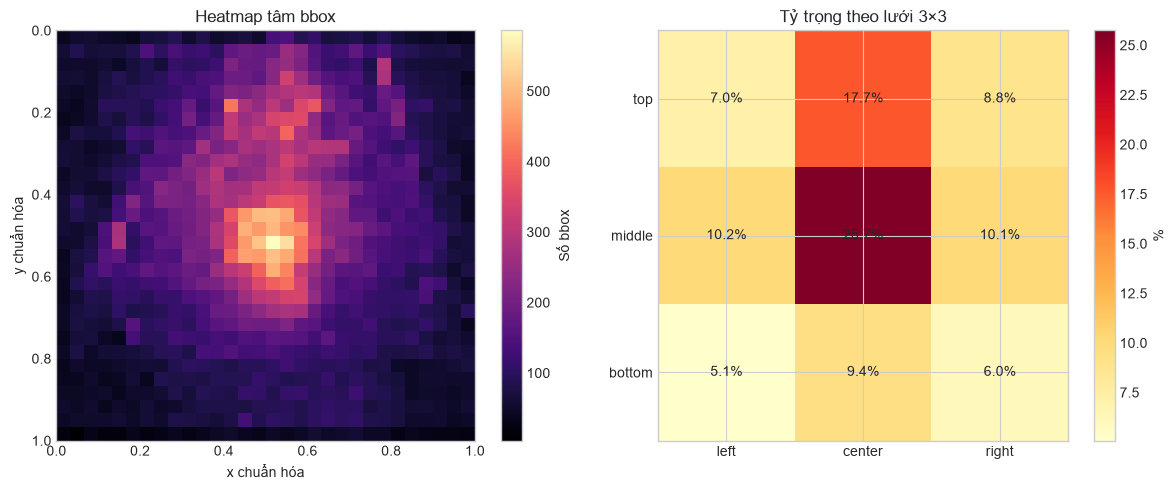

In [13]:
analysis_bbox_df["cx_norm"] = (analysis_bbox_df["x"] + analysis_bbox_df["bbox_w"] / 2) / analysis_bbox_df["image_width"]
analysis_bbox_df["cy_norm"] = (analysis_bbox_df["y"] + analysis_bbox_df["bbox_h"] / 2) / analysis_bbox_df["image_height"]
analysis_bbox_df["spatial_zone"] = np.where(
    analysis_bbox_df["cx_norm"].between(1/3, 2/3, inclusive="left") &
    analysis_bbox_df["cy_norm"].between(1/3, 2/3, inclusive="left"), "center", "edge"
)
zone_dist = analysis_bbox_df["spatial_zone"].value_counts().to_frame("count")
zone_dist["percent"] = zone_dist["count"] / zone_dist["count"].sum() * 100
display(zone_dist)

xbin = pd.cut(analysis_bbox_df["cx_norm"], bins=[-np.inf, 1/3, 2/3, np.inf], labels=["left", "center", "right"], right=False)
ybin = pd.cut(analysis_bbox_df["cy_norm"], bins=[-np.inf, 1/3, 2/3, np.inf], labels=["top", "middle", "bottom"], right=False)
grid_counts = pd.crosstab(ybin, xbin).reindex(index=["top", "middle", "bottom"], columns=["left", "center", "right"], fill_value=0)
grid_pct = grid_counts / grid_counts.to_numpy().sum() * 100
display(grid_pct.round(2).style.format("{:.2f}%").background_gradient(cmap="YlOrRd"))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
h = axes[0].hist2d(analysis_bbox_df["cx_norm"], analysis_bbox_df["cy_norm"], bins=30, range=[[0,1],[0,1]], cmap="magma")
axes[0].invert_yaxis(); axes[0].set(title="Heatmap tâm bbox", xlabel="x chuẩn hóa", ylabel="y chuẩn hóa")
plt.colorbar(h[3], ax=axes[0], label="Số bbox")
im = axes[1].imshow(grid_pct.values, cmap="YlOrRd")
axes[1].set_xticks(range(3), grid_pct.columns); axes[1].set_yticks(range(3), grid_pct.index)
axes[1].set_title("Tỷ trọng theo lưới 3×3")
for i in range(3):
    for j in range(3): axes[1].text(j, i, f"{grid_pct.iloc[i,j]:.1f}%", ha="center", va="center")
plt.colorbar(im, ax=axes[1], label="%")
plt.tight_layout(); plt.show()

In [14]:
center_share = analysis_bbox_df["spatial_zone"].eq("center").mean()
peak_cell = grid_pct.stack().idxmax()
peak_value = grid_pct.stack().max()
bias_ratio = center_share / (1/9)
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- **{center_share:.1%}** tâm object nằm trong ô center, bằng **{bias_ratio:.2f}×** mức kỳ vọng 11.1% nếu phân bố đều.\n"
    f"- Ô tập trung nhất là **{peak_cell[0]}–{peak_cell[1]}**, chứa **{peak_value:.1f}%** object.\n"
    "- Center bias cao có thể làm metric đẹp hơn trên cảnh tương tự nhưng giảm độ bền ở rìa ảnh. "
    "Random crop/translation nên giữ bbox hợp lệ và cần đánh giá riêng center so với edge."
))

**Insight & đánh giá**

- **25.7%** tâm object nằm trong ô center, bằng **2.32×** mức kỳ vọng 11.1% nếu phân bố đều.
- Ô tập trung nhất là **middle–center**, chứa **25.7%** object.
- Center bias cao có thể làm metric đẹp hơn trên cảnh tương tự nhưng giảm độ bền ở rìa ảnh. Random crop/translation nên giữ bbox hợp lệ và cần đánh giá riêng center so với edge.

## 7. Pixel/intensity (histogram pixel RGB, mean/std, brightness/contrast)

Mỗi nhóm split × modality lấy tối đa `PIXEL_SAMPLE_PER_GROUP` ảnh bằng seed cố định. Ảnh được chuyển RGB và resize 128×128. **Brightness** là trung bình luminance `0.2126R + 0.7152G + 0.0722B`; **contrast** là độ lệch chuẩn luminance trong từng ảnh. Đây là ước lượng lấy mẫu, không phải quét pixel toàn bộ dataset.

sampled_images  brightness_mean  \
split modality                                    
train ir                   200          142.264   
      rgb                  200           92.687   
val   ir                   200          126.115   
      rgb                  200          102.603   

                brightness_std_between_images  contrast_mean   mean_R  \
split modality                                                          
train ir                               58.840         50.667  142.264   
      rgb                              40.292         32.627   97.001   
val   ir                               53.924         58.248  126.115   
      rgb                              35.223         36.351  107.813   

                 mean_G   mean_B   std_R   std_G   std_B  channel_delta  
split modality                                                           
train ir        142.264  142.264  50.667  50.667  50.667          0.000  
      rgb        92.355   83.269  34.949  32.758  30.348         23.733  
val   ir        126.115  126.115  58.248  58.248  58.248          0.000  
      rgb       101.800   95.209  38.621  36.490  35.111         22.006

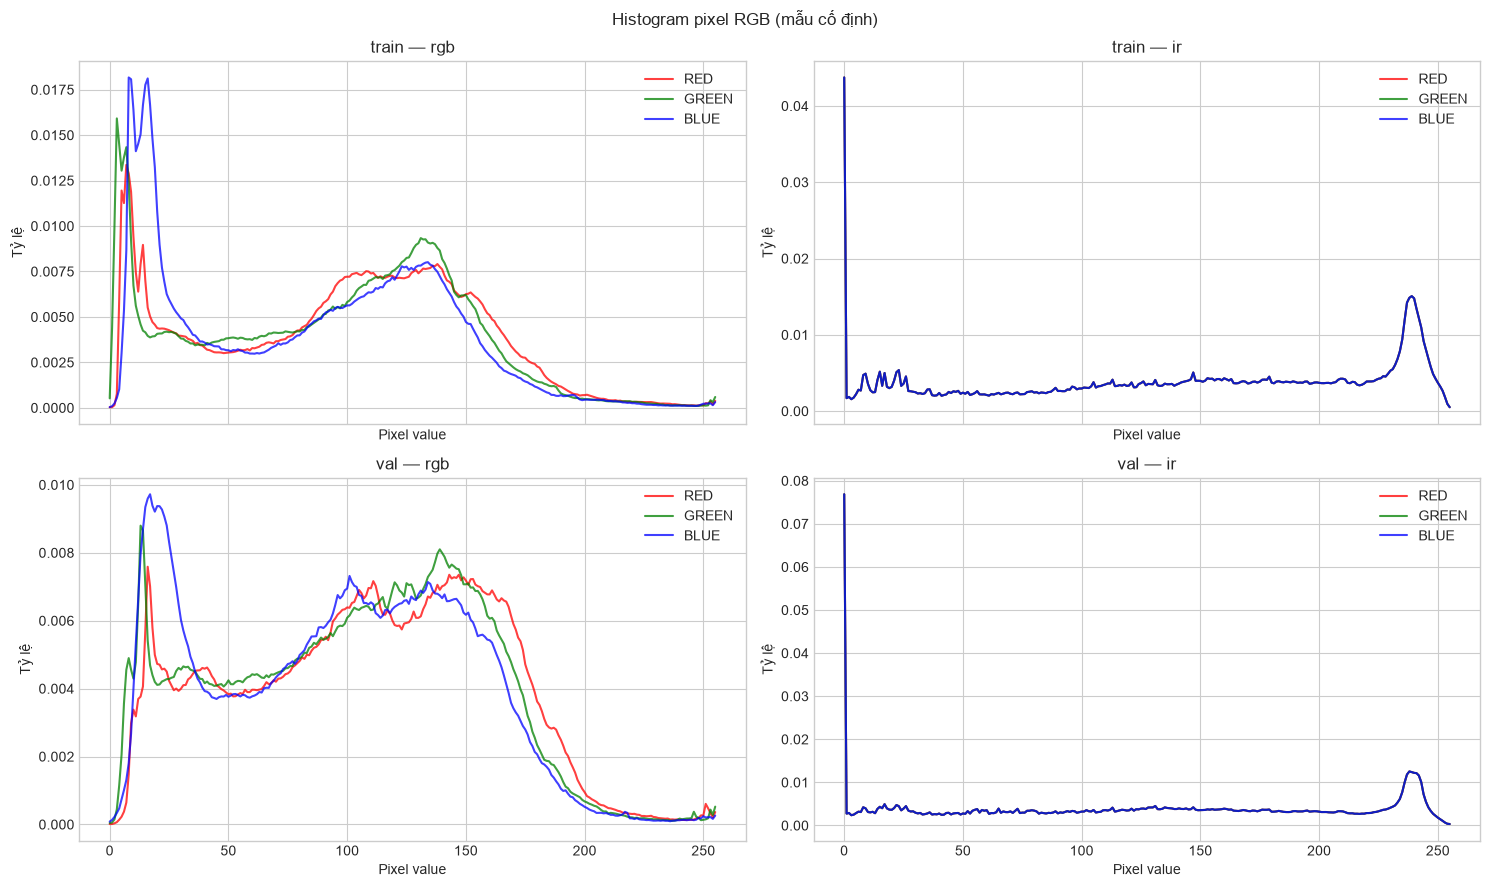

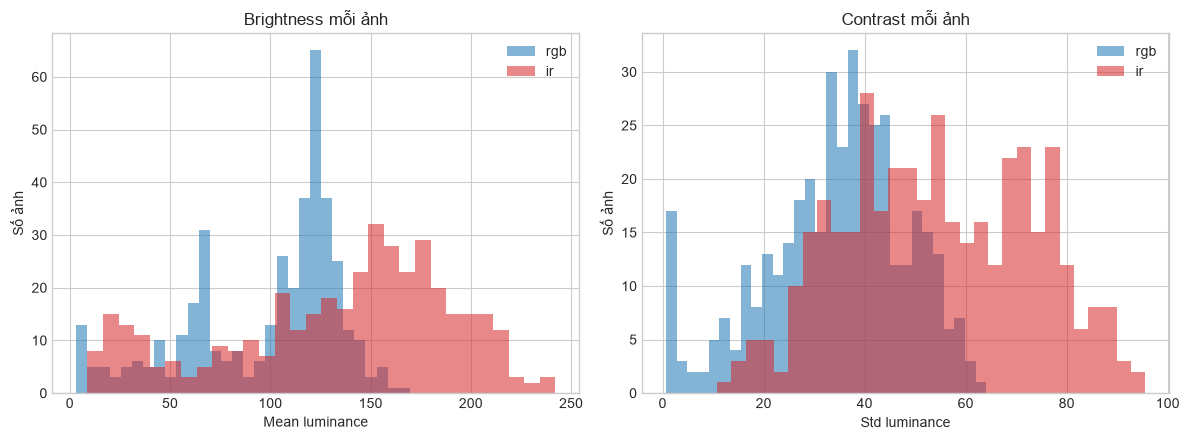

In [15]:
rng = np.random.default_rng(SEED)
pixel_rows = []
histograms = {}

for split in SPLITS:
    for modality in MODALITIES:
        paths = quality_df.loc[
            quality_df["split"].eq(split) & quality_df["modality"].eq(modality) & quality_df["readable"],
            "path"
        ].to_numpy()
        chosen = rng.choice(paths, size=min(PIXEL_SAMPLE_PER_GROUP, len(paths)), replace=False)
        hist = np.zeros((3, 256), dtype=np.int64)
        for path in chosen:
            with Image.open(path) as im:
                arr = np.asarray(im.convert("RGB").resize(PIXEL_RESIZE), dtype=np.uint8)
            flat = arr.reshape(-1, 3)
            for c in range(3): hist[c] += np.bincount(flat[:, c], minlength=256)
            luma = 0.2126 * arr[..., 0] + 0.7152 * arr[..., 1] + 0.0722 * arr[..., 2]
            means = flat.mean(axis=0); stds = flat.std(axis=0)
            pixel_rows.append({
                "split": split, "modality": modality, "file_name": Path(path).name,
                "mean_R": means[0], "mean_G": means[1], "mean_B": means[2],
                "std_R": stds[0], "std_G": stds[1], "std_B": stds[2],
                "brightness": luma.mean(), "contrast": luma.std(),
                "channel_delta": np.abs(flat[:, 0].astype(float)-flat[:, 1]).mean() +
                                 np.abs(flat[:, 1].astype(float)-flat[:, 2]).mean(),
            })
        histograms[(split, modality)] = hist

pixel_df = pd.DataFrame(pixel_rows)
pixel_summary = pixel_df.groupby(["split", "modality"]).agg(
    sampled_images=("file_name", "count"), brightness_mean=("brightness", "mean"),
    brightness_std_between_images=("brightness", "std"), contrast_mean=("contrast", "mean"),
    mean_R=("mean_R", "mean"), mean_G=("mean_G", "mean"), mean_B=("mean_B", "mean"),
    std_R=("std_R", "mean"), std_G=("std_G", "mean"), std_B=("std_B", "mean"),
    channel_delta=("channel_delta", "mean"),
)
display(pixel_summary.round(3))

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
colors = ["red", "green", "blue"]
for i, split in enumerate(SPLITS):
    for j, modality in enumerate(MODALITIES):
        ax = axes[i, j]
        hist = histograms[(split, modality)]
        for c, color in enumerate(colors):
            density = hist[c] / max(hist[c].sum(), 1)
            ax.plot(np.arange(256), density, color=color, alpha=.75, label=color.upper())
        ax.set(title=f"{split} — {modality}", xlabel="Pixel value", ylabel="Tỷ lệ")
        ax.legend()
plt.suptitle("Histogram pixel RGB (mẫu cố định)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for modality, color in [("rgb", "tab:blue"), ("ir", "tab:red")]:
    d = pixel_df[pixel_df["modality"].eq(modality)]
    axes[0].hist(d["brightness"], bins=30, alpha=.55, label=modality, color=color)
    axes[1].hist(d["contrast"], bins=30, alpha=.55, label=modality, color=color)
axes[0].set(title="Brightness mỗi ảnh", xlabel="Mean luminance", ylabel="Số ảnh")
axes[1].set(title="Contrast mỗi ảnh", xlabel="Std luminance", ylabel="Số ảnh")
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

In [16]:
mod_stats = pixel_df.groupby("modality").agg(
    brightness=("brightness", "mean"), contrast=("contrast", "mean"),
    mean_R=("mean_R", "mean"), mean_G=("mean_G", "mean"), mean_B=("mean_B", "mean"),
    channel_delta=("channel_delta", "mean"),
)
rgb_stats = mod_stats.loc["rgb"]
ir_stats = mod_stats.loc["ir"]
ir_is_gray = ir_stats["channel_delta"] < 1.0
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- RGB có brightness/contrast trung bình **{rgb_stats['brightness']:.1f}/{rgb_stats['contrast']:.1f}**; "
    f"IR là **{ir_stats['brightness']:.1f}/{ir_stats['contrast']:.1f}** trên thang 0–255.\n"
    f"- Độ lệch kênh trung bình của IR là **{ir_stats['channel_delta']:.3f}**; "
    f"ảnh IR {'gần như grayscale dù lưu 3 kênh' if ir_is_gray else 'có khác biệt đáng kể giữa các kênh'}.\n"
    "- RGB và IR có miền cường độ khác nhau; nên normalize từng modality riêng, đồng thời theo dõi ảnh quá tối/sáng khi augmentation quang học. "
    "Không áp dụng color jitter RGB một cách máy móc cho IR."
))

**Insight & đánh giá**

- RGB có brightness/contrast trung bình **97.6/34.5**; IR là **134.2/54.5** trên thang 0–255.
- Độ lệch kênh trung bình của IR là **0.000**; ảnh IR gần như grayscale dù lưu 3 kênh.
- RGB và IR có miền cường độ khác nhau; nên normalize từng modality riêng, đồng thời theo dõi ảnh quá tối/sáng khi augmentation quang học. Không áp dụng color jitter RGB một cách máy móc cho IR.

## Kết luận và xuất báo cáo Markdown

In [17]:
def fmt_table(df, index=True, floatfmt=",.2f"):
    return df.to_markdown(index=index, floatfmt=floatfmt)

class_report = class_dist.copy()
class_report.index.name = "class"
size_report = size_dist.copy()
size_report.index.name = "size"
quality_summary = pd.DataFrame({
    "Hạng mục": [
        "Ảnh kỳ vọng", "Ảnh thiếu", "Ảnh corrupt/unreadable", "Ảnh lệch metadata",
        "Cặp RGB–IR lệch kích thước", "XML thiếu", "COCO bbox sai hình học",
        "Ảnh COCO không có object", "Sidecar annotation không phải XML"
    ],
    "Số lượng": [len(quality_df), n_missing_img, n_corrupt, n_size_mismatch, n_pair_mismatch,
                  n_missing_xml, n_wrong_bbox, n_empty, len(unexpected_sidecars)]
})
spatial_report = zone_dist.copy()
spatial_report.index.name = "zone"

report = f'''# Báo cáo Exploratory Data Analysis — VTUAV-det

**Ngày phân tích:** {pd.Timestamp.now().strftime('%d/%m/%Y')}  
**Nguồn dữ liệu:** `VTUAV-det/`  
**Notebook tái lập:** [`VTUAV-det_EDA.ipynb`](./VTUAV-det_EDA.ipynb)

## Tóm tắt kết quả

VTUAV-det có **{len(images_df):,} sample ghép cặp RGB–IR**, **{2*len(images_df):,} ảnh kỳ vọng**, **{len(anns_df):,} object** và **{len(CAT_MAP)} class**. Train/validation chiếm {train_share:.1%}/{1-train_share:.1%}. Annotation chính là COCO JSON; `val_ir.json` ánh xạ tới thư mục vật lý `test/`.

Các điểm đáng chú ý:

- Phát hiện **{n_missing_img} ảnh thiếu**, **{n_corrupt} ảnh corrupt**, **{n_size_mismatch} ảnh lệch metadata**, **{n_pair_mismatch} cặp lệch kích thước**.
- COCO có **{n_wrong_bbox} bbox sai hình học** và **{n_empty} ảnh không có object**.
- XML phụ thiếu **{n_missing_xml} file**; **{n_missing_xml_empty}** trường hợp là ảnh COCO không có object và **{n_missing_xml_with_objects}** trường hợp có object. Có **{len(unexpected_sidecars)} sidecar không phải XML**.
- `{majority_class}` chiếm **{class_dist.loc[majority_class, 'percent']:.1f}%** object; mất cân bằng lớn nhất/nhỏ nhất là **{imbalance_ratio:.1f}:1**.
- **{small_share:.1%}** bbox là small; median bbox chiếm **{median_area_ratio:.3%}** diện tích ảnh.
- **{center_share:.1%}** tâm object ở center, bằng **{bias_ratio:.2f}×** mức kỳ vọng đồng đều.
- RGB có brightness/contrast **{rgb_stats['brightness']:.1f}/{rgb_stats['contrast']:.1f}**, IR **{ir_stats['brightness']:.1f}/{ir_stats['contrast']:.1f}** (ước lượng lấy mẫu, thang 0–255).

---

## 1. Dataset overview

{fmt_table(overview_df)}

### Class và format

{fmt_table(categories, index=False)}

- Ảnh: JPEG trong `<split>/rgb/` và `<split>/ir/`.
- Annotation chính: COCO JSON, bbox `[x, y, width, height]`.
- Annotation phụ: Pascal VOC XML, bbox `xmin, ymin, xmax, ymax`.
- Split logic `val` nằm trong thư mục vật lý `test`.

### Insight và đánh giá

Dataset có {overview_df.loc['train', 'paired_samples_COCO']:,} train và {overview_df.loc['val', 'paired_samples_COCO']:,} val, cùng dùng {len(CAT_MAP)} class. Cấu trúc cặp RGB–IR phù hợp cho mô hình fusion; cần giữ phép biến đổi hình học đồng bộ. Nên dùng COCO JSON làm nguồn nhãn chuẩn để tránh phụ thuộc độ đầy đủ của XML.

---

## 2. Data quality check

{fmt_table(quality_summary, index=False, floatfmt='g')}

### Chi tiết annotation COCO

{fmt_table(annotation_audit, floatfmt='g')}

### Insight và đánh giá

Trên {len(quality_df):,} ảnh kỳ vọng có {n_missing_img} ảnh thiếu và {n_corrupt} ảnh corrupt. COCO có {n_wrong_bbox} bbox sai hình học; ảnh không có object ({n_empty}) cần được xem là negative sample cho đến khi có xác nhận khác. XML thiếu {n_missing_xml} file; {n_missing_xml_empty} ảnh tương ứng là negative theo COCO và {n_missing_xml_with_objects} ảnh có object. Vì vậy, trình đọc XML cần quy ước rõ file vắng mặt có phải nhãn rỗng hay lỗi dữ liệu. Các sidecar không phải XML: `{', '.join(x['file'] for x in unexpected_sidecars) if unexpected_sidecars else 'không có'}`.

---

## 3. Image Resolution Analysis

Top cấu hình độ phân giải:

{fmt_table(resolution_table.sort_values(['modality','count'], ascending=[True,False]).head(20), index=False)}

### Insight và đánh giá

Độ phân giải phổ biến nhất là **{top_res}** ({top_res_share:.1%}); có {valid_quality['resolution'].nunique()} cấu hình, aspect ratio {ar_min:.3f}–{ar_max:.3f}. Dù cặp modality có thể đồng kích thước, pipeline vẫn nên resize/letterbox nhất quán và biến đổi đồng bộ với bbox.

---

## 4. Class distribution

{fmt_table(class_report)}

### Insight và đánh giá

`{majority_class}` là class lớn nhất ({class_dist.loc[majority_class, 'percent']:.1f}%), `{minority_class}` nhỏ nhất ({class_dist.loc[minority_class, 'percent']:.1f}%), tỷ lệ {imbalance_ratio:.1f}:1. Chênh tỷ trọng train–val lớn nhất là `{max_shift_class}` ({max_shift:.2f} điểm %). Nên theo dõi AP từng class và cân nhắc weighting/sampling.

---

## 5. Bounding box

{fmt_table(size_report)}

Thống kê object/ảnh:

{fmt_table(objects_per_image.groupby('split')['objects'].describe(percentiles=[.25,.5,.75,.9,.95,.99]))}

### Insight và đánh giá

Sau khi loại {n_wrong_bbox} bbox sai hình học, small chiếm **{small_share:.1%}** bbox hợp lệ; median diện tích tương đối là **{median_area_ratio:.3%}**. Median aspect ratio là {median_ar:.2f}; bbox cực đoan chiếm {extreme_ar_share:.2%}. Median object/ảnh là {median_obj:.0f}, p95 {p95_obj:.0f}. Nên ưu tiên feature độ phân giải cao/multi-scale và kiểm tra giới hạn max detections.

---

## 6. Spatial distribution

{fmt_table(spatial_report)}

Lưới 3×3 (%):

{fmt_table(grid_pct.round(2))}

### Insight và đánh giá

Center chứa **{center_share:.1%}** object, bằng {bias_ratio:.2f}× mức kỳ vọng đều. Ô dày nhất là {peak_cell[0]}–{peak_cell[1]} ({peak_value:.1f}%). Nên dùng crop/translation hợp lệ và đánh giá riêng center/edge để kiểm tra độ bền vị trí.

---

## 7. Pixel / intensity

Thống kê lấy mẫu (tối đa {PIXEL_SAMPLE_PER_GROUP} ảnh / split / modality, resize {PIXEL_RESIZE[0]}×{PIXEL_RESIZE[1]}):

{fmt_table(pixel_summary)}

### Insight và đánh giá

RGB có brightness/contrast trung bình **{rgb_stats['brightness']:.1f}/{rgb_stats['contrast']:.1f}**, IR **{ir_stats['brightness']:.1f}/{ir_stats['contrast']:.1f}**. IR {'gần như grayscale lưu 3 kênh' if ir_is_gray else 'có khác biệt kênh đáng kể'}. Nên normalize từng modality riêng; color augmentation cho RGB và IR không nên dùng chung một cách máy móc.

---

## Khuyến nghị cho modeling

1. Dùng COCO JSON làm annotation chuẩn; nếu framework yêu cầu XML, quy ước rõ ảnh negative có XML rỗng hay không có file và chuyển đổi nhất quán từ JSON.
2. Xử lý/loại bbox sai sau khi kiểm tra trực quan; giữ ảnh không object như negative sample nếu đúng chủ đích.
3. Áp dụng augmentation hình học đồng bộ cho RGB–IR–bbox; normalize hai modality riêng.
4. Ưu tiên kiến trúc và kích thước input phù hợp small object; cân nhắc multi-scale training/tiling.
5. Báo cáo AP theo class, APs/APm/APl và metric center/edge; giám sát class imbalance và positional bias.

## Tính tái lập

- Kiểm tra corrupt/kích thước: toàn bộ ảnh bằng Pillow `verify()`.
- Pixel statistics: seed `{SEED}`, tối đa `{PIXEL_SAMPLE_PER_GROUP}` ảnh mỗi split × modality, resize `{PIXEL_RESIZE[0]}×{PIXEL_RESIZE[1]}`.
- Toàn bộ bảng và biểu đồ chi tiết nằm trong notebook cùng tên.
'''

REPORT_PATH = Path.cwd() / "VTUAV-det_EDA.md"
REPORT_PATH.write_text(report, encoding="utf-8")
print(f"Đã ghi báo cáo: {REPORT_PATH.resolve()}")
display(Markdown("**Hoàn tất:** notebook đã chạy toàn bộ và báo cáo Markdown đã được xuất."))

Đã ghi báo cáo: G:\Capstone\code\Data\VTUAV-det_EDA.md


**Hoàn tất:** notebook đã chạy toàn bộ và báo cáo Markdown đã được xuất.